In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("Walmart.csv")

In [4]:
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,$74.69,7.0,05-01-2019,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,$15.28,5.0,08-03-2019,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,$46.33,7.0,03-03-2019,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,$58.22,8.0,27-01-2019,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,$86.31,7.0,08-02-2019,10:37:00,Ewallet,5.3,0.48


In [5]:
df.shape

(10051, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10051 entries, 0 to 10050
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10051 non-null  int64  
 1   Branch          10051 non-null  object 
 2   City            10051 non-null  object 
 3   category        10051 non-null  object 
 4   unit_price      10020 non-null  object 
 5   quantity        10020 non-null  float64
 6   date            10051 non-null  object 
 7   time            10051 non-null  object 
 8   payment_method  10051 non-null  object 
 9   rating          10051 non-null  float64
 10  profit_margin   10051 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 863.9+ KB


In [7]:
df.describe()

,invoice_id,quantity,rating,profit_margin
count,10051.000000,10020.000000,10051.000000,10051.000000
mean,5025.741220,2.353493,5.825659,0.393791
std,2901.174372,1.602658,1.763991,0.090669
min,1.000000,1.000000,3.000000,0.180000
25%,2513.500000,1.000000,4.000000,0.330000
50%,5026.000000,2.000000,6.000000,0.330000
75%,7538.500000,3.000000,7.000000,0.480000
max,10000.000000,10.000000,10.000000,0.570000


In [13]:
df.isnull().sum()

invoice_id         0
Branch             0
City               0
category           0
unit_price        31
quantity          31
date               0
time               0
payment_method     0
rating             0
profit_margin      0
dtype: int64

In [14]:
df.duplicated().sum()

0

In [15]:
df.drop_duplicates(inplace=True)

In [18]:
df["unit_price"].head(10)

0    $74.69
1    $15.28
2    $46.33
3    $58.22
4    $86.31
5    $85.39
6    $68.84
7    $73.56
8    $36.26
9    $54.84
Name: unit_price, dtype: object

In [19]:
# Remove '$' from unit_price
df["unit_price"] = df["unit_price"].str.replace("$", "", regex=False)

# Convert to float
df["unit_price"] = pd.to_numeric(df["unit_price"])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10000 non-null  int64  
 1   Branch          10000 non-null  object 
 2   City            10000 non-null  object 
 3   category        10000 non-null  object 
 4   unit_price      9969 non-null   float64
 5   quantity        9969 non-null   float64
 6   date            10000 non-null  object 
 7   time            10000 non-null  object 
 8   payment_method  10000 non-null  object 
 9   rating          10000 non-null  float64
 10  profit_margin   10000 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 937.5+ KB


# Create a Total Sales Column

In [21]:
df["Total_Sales"] = df["unit_price"] * df["quantity"]

In [22]:
df[["unit_price", "quantity", "Total_Sales"]].head()

,unit_price,quantity,Total_Sales
0,74.69,7.0,522.83
1,15.28,5.0,76.40
2,46.33,7.0,324.31
3,58.22,8.0,465.76
4,86.31,7.0,604.17


# Total Sales by Category

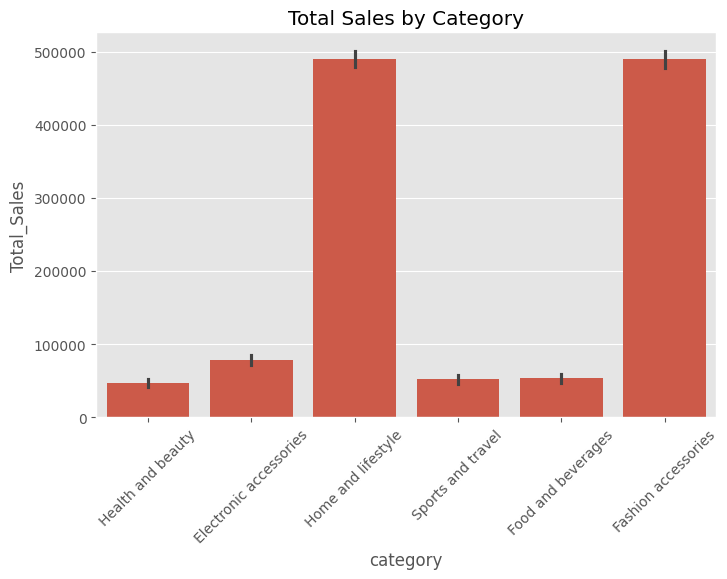

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="category", y="Total_Sales", estimator=sum)
plt.xticks(rotation=45)
plt.title("Total Sales by Category")
plt.show()

# Sales by City

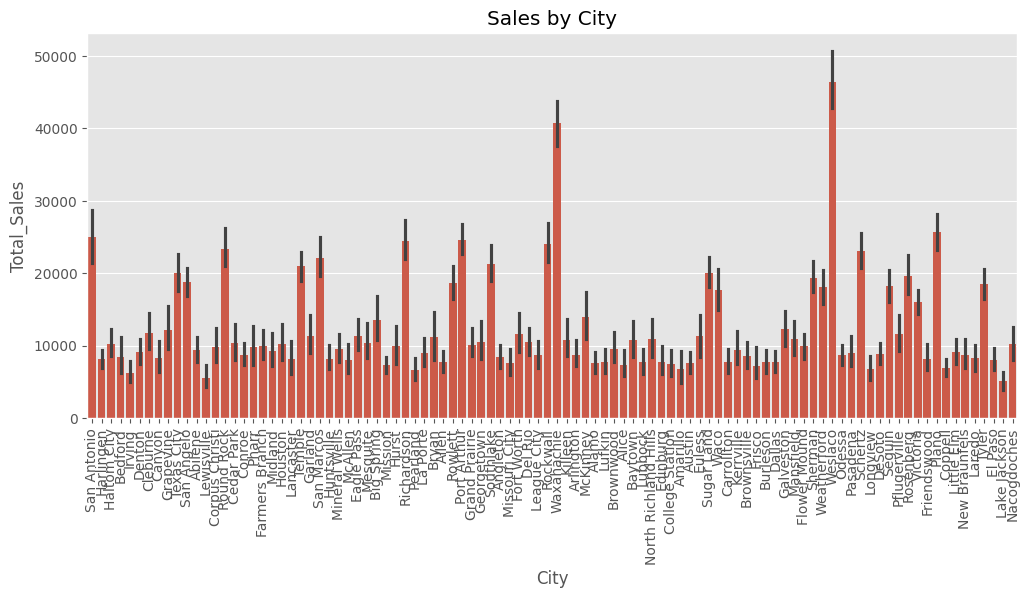

In [24]:
plt.figure(figsize=(12,5))
sns.barplot(data=df, x="City", y="Total_Sales", estimator=sum)
plt.xticks(rotation=90)
plt.title("Sales by City")
plt.show()

# Payment Method Distribution

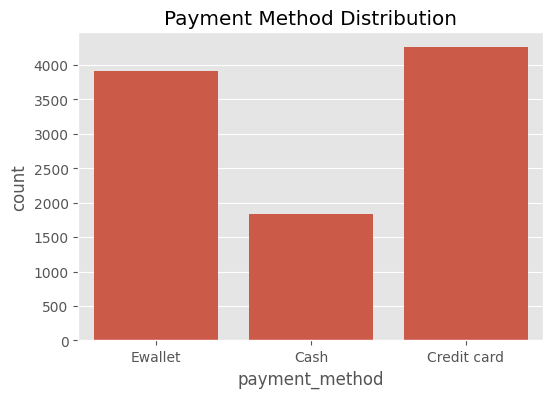

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="payment_method")
plt.title("Payment Method Distribution")
plt.show()

# Customer Rating Distribution

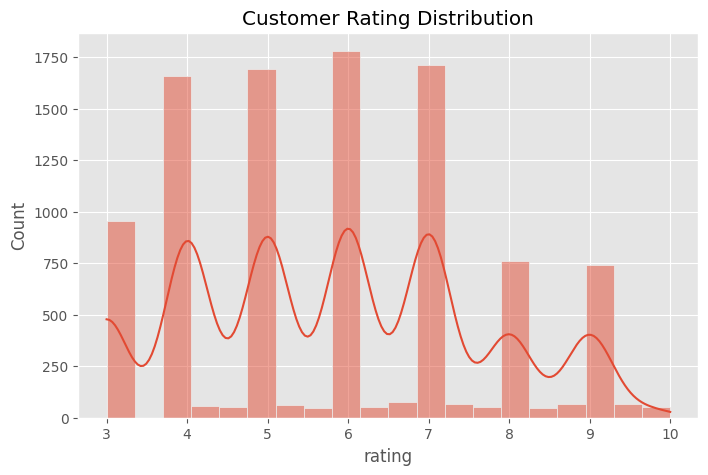

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df["rating"], bins=20, kde=True)
plt.title("Customer Rating Distribution")
plt.show()

# Quantity Sold Distribution

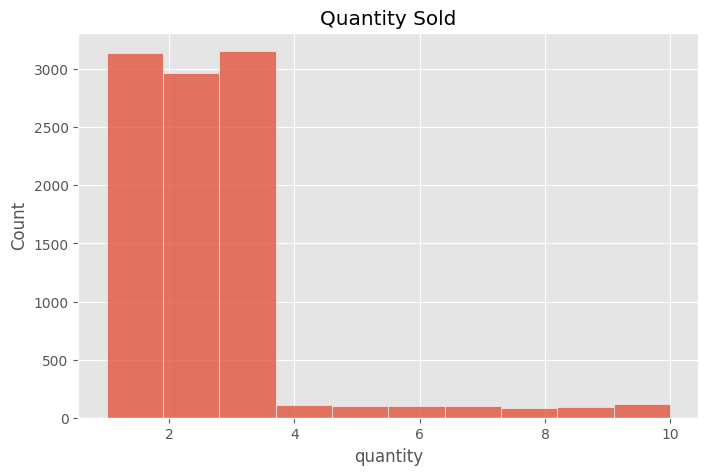

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["quantity"], bins=10)
plt.title("Quantity Sold")
plt.show()

# Profit Margin by Category

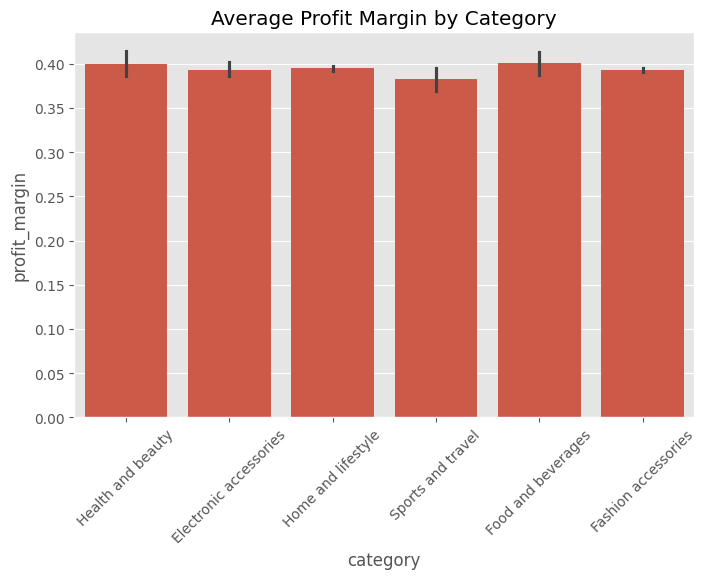

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="category", y="profit_margin", estimator="mean")
plt.xticks(rotation=45)
plt.title("Average Profit Margin by Category")
plt.show()

# Top 10 Cities by Sales

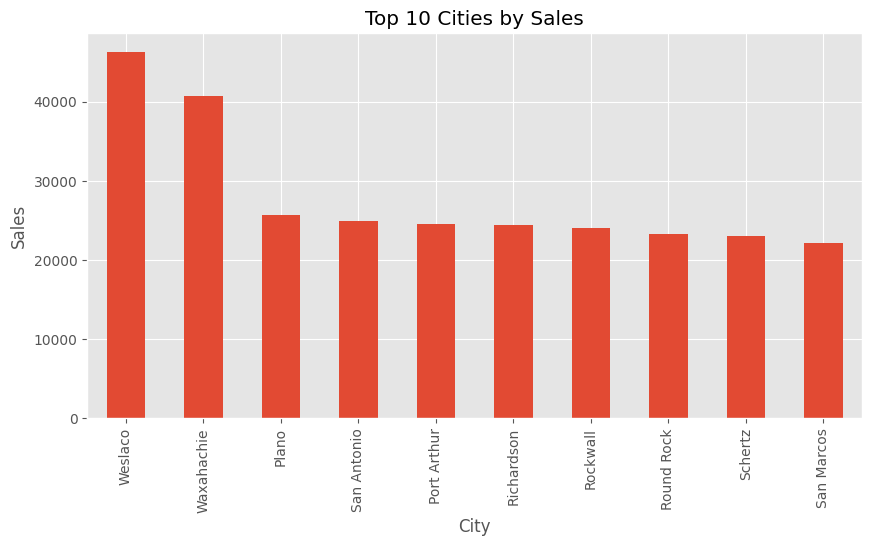

In [29]:
top_city = df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False).head(10)

top_city.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Cities by Sales")
plt.ylabel("Sales")
plt.show()

# Correlation Heatmap

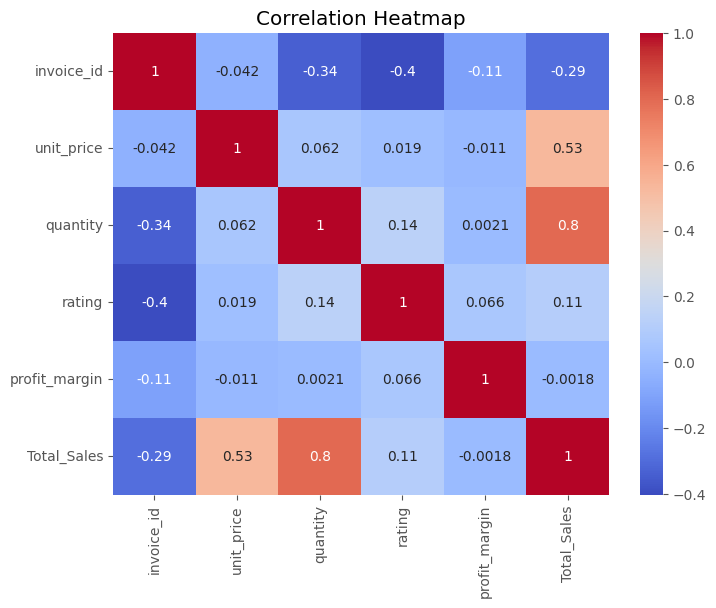

In [30]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Sales Distribution

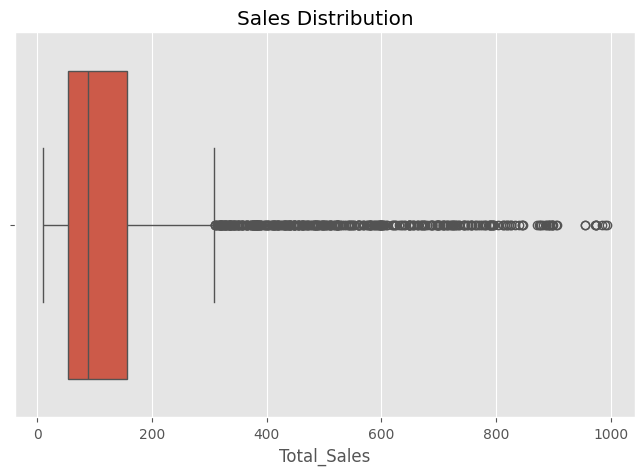

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Total_Sales"])
plt.title("Sales Distribution")
plt.show()

# Monthly Sales Trend

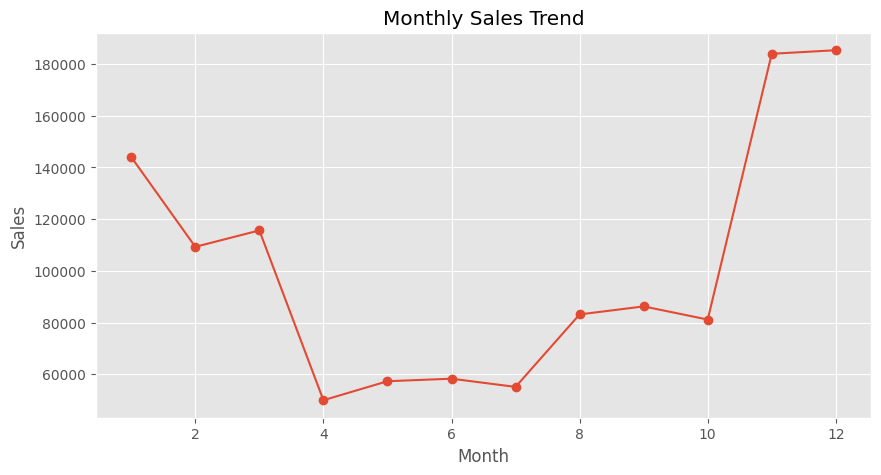

In [32]:
df["date"] = pd.to_datetime(df["date"], format="mixed")

monthly_sales = df.groupby(df["date"].dt.month)["Total_Sales"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [34]:
total_sales = df["Total_Sales"].sum()

avg_sales = df["Total_Sales"].mean()

total_orders = len(df)

avg_rating = df["rating"].mean()

print("Total Sales :", round(total_sales,2))
print("Average Sales :", round(avg_sales,2))
print("Total Orders :", total_orders)
print("Average Rating :", round(avg_rating,2))

Total Sales : 1209726.38
Average Sales : 121.35
Total Orders : 10000
Average Rating : 5.83
